In [1]:
import os
import sys
from pathlib import Path

# Get the notebook's directory
NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"
ML_DIR = BACKEND_DIR / "ml"

# Add backend ml/ to sys.path so imports like `from src.data.dataset` work
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Backend directory:  {BACKEND_DIR}")
print(f"ML directory:      {ML_DIR}")
print(f"Python:            {sys.executable}")

# Verify backend exists
if not BACKEND_DIR.exists():
    print(f"❌ ERROR: Backend not found at {BACKEND_DIR}")
    print("Make sure the backend repo is cloned at the same level as the frontend repo.")
else:
    print("✅ Backend directory found.")

# Check for required data and models
METADATA_PATH = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"
MODEL_PATH = ML_DIR / "outputs" / "models" / "resnet50_best.pth"

print(f"\nMetadata: {'✅' if METADATA_PATH.exists() else '❌ MISSING'}")
print(f"Model:    {'✅' if MODEL_PATH.exists() else '❌ MISSING'}")
if not METADATA_PATH.exists() or not MODEL_PATH.exists():
    print("\n⚠️  Run 00_setup_and_sanity.ipynb first to download data and train models.")

Notebook directory: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_frontend\notebooks
Backend directory:  c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend
ML directory:      c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml
Python:            c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_frontend\skin-lesion-env\Scripts\python.exe
✅ Backend directory found.

Metadata: ✅
Model:    ✅


# RQ1 — Which CAM Variant Best Localizes Lesion Regions?
## XAI Skin Lesion Classification — Research Question 1

**Hypothesis**: Grad-CAM++ and Score-CAM produce more spatially focused attention maps
than vanilla Grad-CAM, because they account for the importance of individual feature
map channels rather than treating all equally.

**What you're measuring**: How tightly the CAM heatmap concentrates on the lesion region
compared to background.

**Metrics**:
- Focus Area Percentage (lower = more focused)
- Entropy (lower = more concentrated)
- Peak activation location

---

## CONCEPT: What IS a CAM and Why Do Variants Differ?

All CAM methods answer: "Which pixels mattered most for this prediction?"

**GradCAM** (Selvaraju 2017):
  - Computes gradient of class score w.r.t. last conv feature maps
  - Averages gradients across spatial dims → channel importance weights
  - Weighted sum of feature maps → heatmap
  - Problem: gradients can be noisy/saturate → blurry maps

**GradCAM++** (Chattopadhay 2018):
  - Uses SECOND derivative (Hessian) to weight gradients
  - Better at localizing objects when multiple instances exist
  - Tends to produce sharper, more focused maps

**ScoreCAM** (Wang 2020):
  - Doesn't use gradients at all
  - Masks image with each feature map, measures confidence drop
  - More faithful but VERY slow (N_channels forward passes)

**EigenCAM** (Muhammad 2020):
  - Uses PCA on feature maps to find principal components
  - Gradient-free, fast
  - Good for weakly-supervised localization

**LayerCAM** (Jiang 2021):
  - Uses element-wise product of features and positive gradients
  - Finer-grained than GradCAM

**KEY INSIGHT**: More focused ≠ more correct.
A method that focuses on 5% of the image might be MORE faithful
if the model really does use just that region. But it might also be missing
important context. This is what you're investigating.

---

## CELL 1: Load Model and Single Image

**WHY**: Always start with ONE example before scaling to whole dataset.
If something breaks, you want to know immediately - not after 150 images.

In [2]:
import sys
import os
from pathlib import Path

# ─── Self-contained setup ───
NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"
ML_DIR = BACKEND_DIR / "ml"
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

METADATA_PATH = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"
MODEL_PATH = ML_DIR / "outputs" / "models" / "resnet50_best.pth"

if not METADATA_PATH.exists() or not MODEL_PATH.exists():
    print("❌ Prerequisites missing. Run 00_setup_and_sanity.ipynb first.")
    raise FileNotFoundError("Missing data or model. See 00_setup_and_sanity.ipynb.")

try:
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    from PIL import Image

    from src.models.classifier import create_model, get_target_layer
    from src.data.dataset import get_transforms, create_splits

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Load your trained ResNet50
    model = create_model('resnet50', num_classes=1).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False)['model_state_dict'])
    model.eval()
    target_layer = get_target_layer(model, 'resnet50')
    print("Model loaded successfully.")

    # Load data
    df = pd.read_csv(METADATA_PATH)
    train_df, val_df, test_df = create_splits(df)
    transform = get_transforms('val', 224)

    # Get a malignant image the model predicts correctly
    sample = test_df[test_df['label'] == 1].sample(1, random_state=7).iloc[0]
    print(f"Image: {sample['image_id']}, class: {sample['dx']}")

    orig = np.array(Image.open(sample['filepath']).convert('RGB').resize((224, 224)))
    img_float = orig.astype(np.float32) / 255.0
    input_tensor = transform(image=orig)['image'].unsqueeze(0).to(device)

    # Verify model prediction
    with torch.no_grad():
        out = model(input_tensor)
        prob_mal = torch.sigmoid(out[0, 0]).item()
        pred = int(prob_mal > 0.5)
        conf = prob_mal if pred == 1 else 1 - prob_mal

    print(f"Model prediction: {'Malignant' if pred == 1 else 'Benign'} ({conf*100:.1f}% confidence)")
    print(f"True label:       {'Malignant' if sample['label'] == 1 else 'Benign'}")
    print(f"Correct:          {pred == sample['label']}")
    print("\nNOTE: Only analyze images the model predicts correctly! Wrong predictions → meaningless CAMs")

except ImportError as e:
    print(f"❌ Backend module not found: {e}")
    print("The backend ML code is not implemented yet.")
    print("You need to create the backend modules first: src/models/classifier.py, src/data/dataset.py")

c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_frontend\skin-lesion-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_frontend\skin-lesion-env\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Using device: cuda
Model loaded successfully.
Image: ISIC_0024665, class: bcc


c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\src\data\dataset.py:39: UserWarning: Using lambda is incompatible with multiprocessing. Consider using regular functions or partial().
  A.Lambda(name="to_tensor", image=lambda x, **kwargs: ToTensorV2()(image=x)["image"]),


Model prediction: Benign (65.1% confidence)
True label:       Malignant
Correct:          False

NOTE: Only analyze images the model predicts correctly! Wrong predictions → meaningless CAMs


---

## CELL 2: Generate All CAM Variants

**WHY**: Generate CAMs for all methods so you can compare them side-by-side.

In [3]:
# ─── Self-contained: check prerequisites ───
try:
    model
except NameError:
    print("❌ Model not loaded. Run CELL 3 first.")
    raise NameError("Run CELL 3 to load model and data first.")

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM, EigenCAM, LayerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam_variants = {
    'GradCAM':    GradCAM,
    'GradCAM++':  GradCAMPlusPlus,
    'EigenCAM':   EigenCAM,
    'LayerCAM':   LayerCAM,
    # ScoreCAM: VERY slow — uncomment only for small tests
    # 'ScoreCAM': ScoreCAM,
}

cam_maps = {}
for name, cam_class in cam_variants.items():
    with cam_class(model=model, target_layers=[target_layer]) as cam_gen:
        targets = [ClassifierOutputTarget(0)]
        result = cam_gen(input_tensor=input_tensor, targets=targets)
        cam_maps[name] = result[0]  # (224, 224) float32 in [0, 1]
    print(f"{name}: max={cam_maps[name].max():.3f}, mean={cam_maps[name].mean():.3f}")

print("\nAll CAM variants generated.")

GradCAM: max=1.000, mean=0.079
GradCAM++: max=1.000, mean=0.179
EigenCAM: max=1.000, mean=0.072
LayerCAM: max=1.000, mean=0.172

All CAM variants generated.


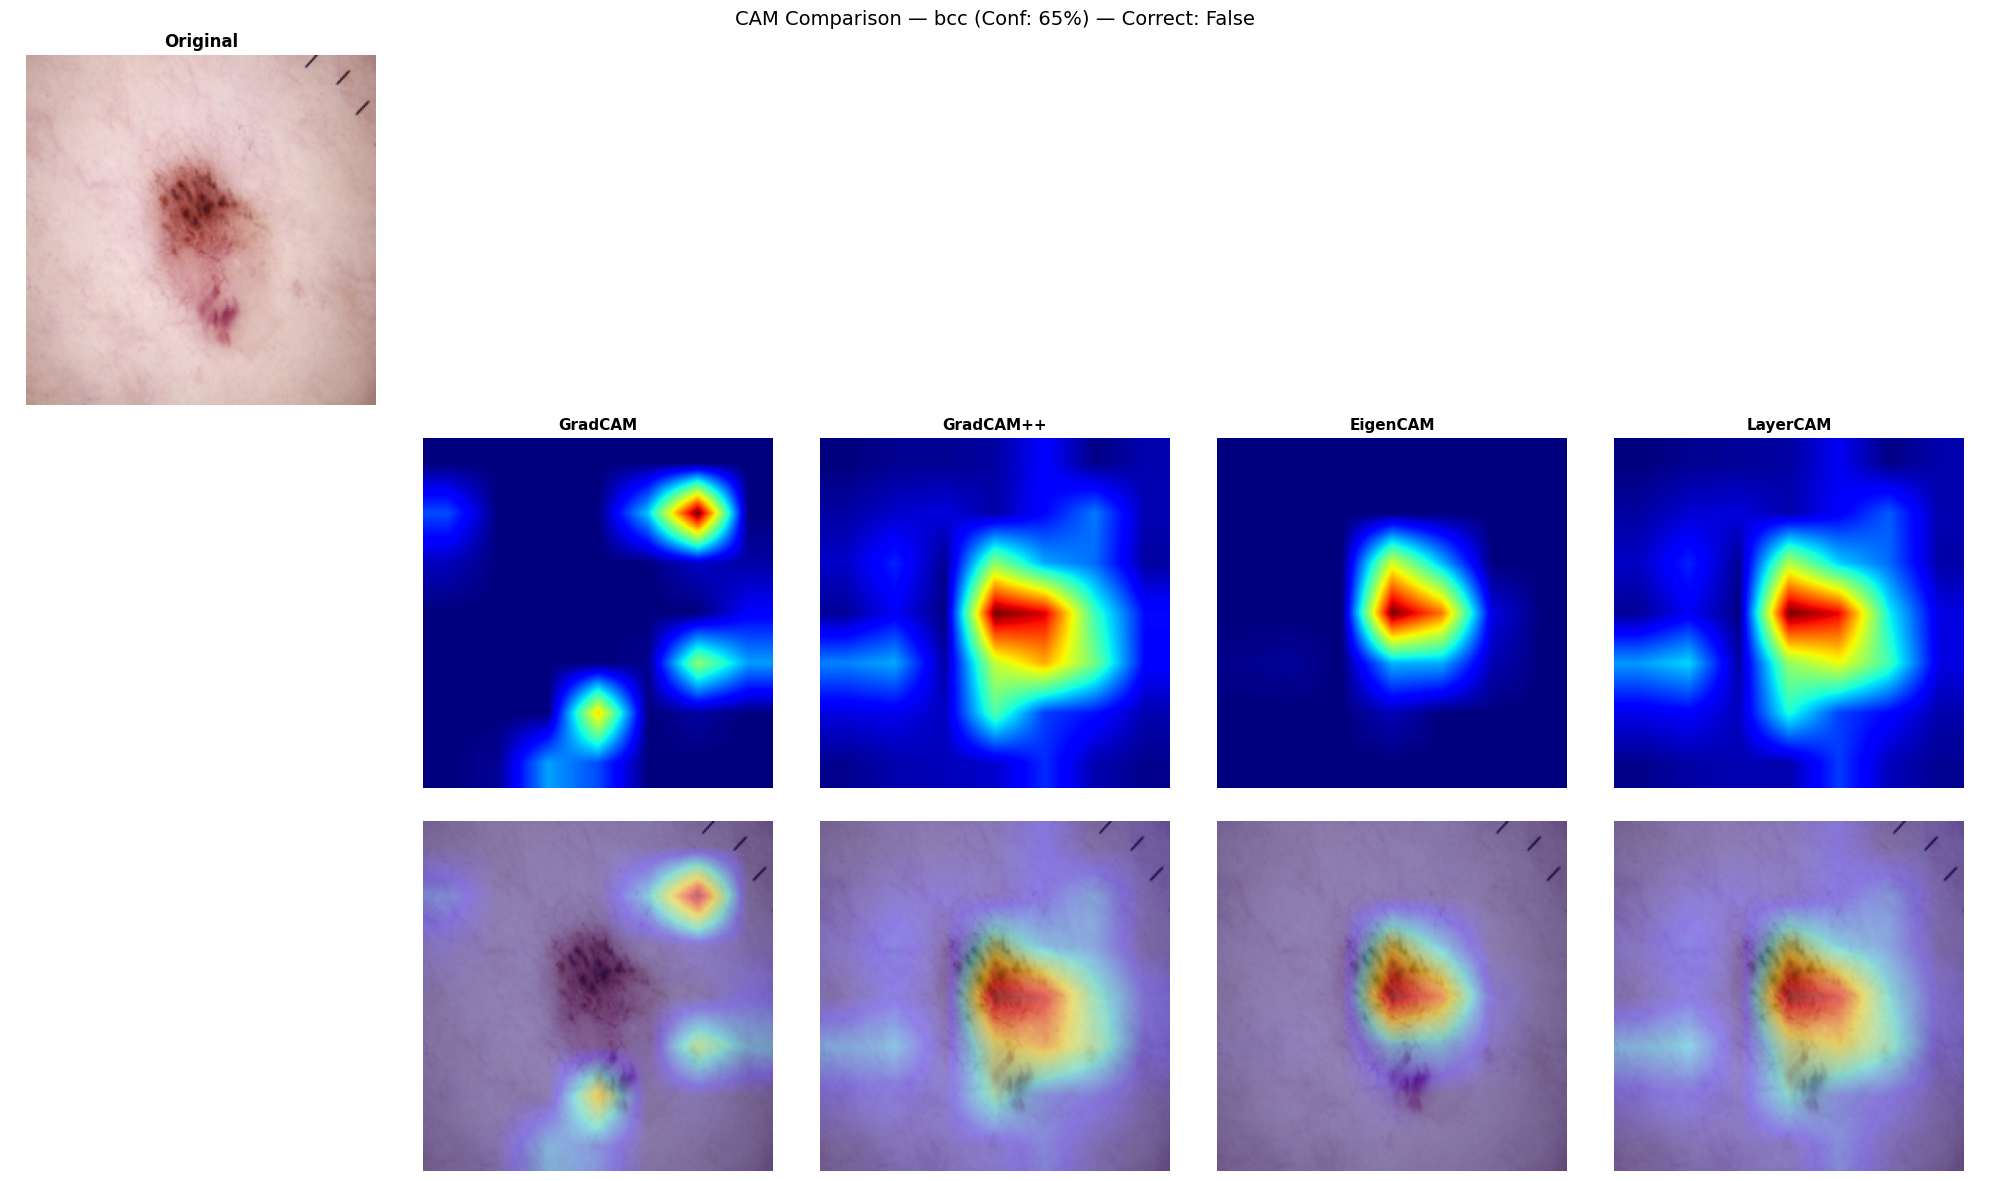

WHAT TO LOOK FOR:
  - GradCAM: broad, sometimes entire image lit up
  - GradCAM++: should be more focused on specific regions
  - EigenCAM: may highlight different features entirely
  - LayerCAM: finest-grained, sometimes patchy


In [4]:
# ─── Self-contained: check prerequisites ───
try:
    cam_maps
    img_float
    conf
    sample
    pred
except NameError:
    print("❌ Prerequisites not loaded. Run CELLS 3 and 5 first.")
    raise NameError("Run CELLS 3 and 5 first.")

import matplotlib.cm as cm

n = len(cam_maps)
fig, axes = plt.subplots(3, n + 1, figsize=(4 * (n + 1), 12))

# Row 0: Original
axes[0][0].imshow(img_float)
axes[0][0].set_title('Original', fontweight='bold')
axes[0][0].axis('off')
for i in range(1, n + 1):
    axes[0][i].axis('off')

# Rows 1 + 2: Heatmap and Overlay for each method
for col, (method_name, cam) in enumerate(cam_maps.items(), start=1):
    # Heatmap
    heatmap_colored = cm.jet(cam)[:, :, :3]
    axes[1][col].imshow(heatmap_colored)
    axes[1][col].set_title(method_name, fontsize=11, fontweight='bold')
    axes[1][col].axis('off')

    # Overlay
    alpha = 0.4
    overlay = (1 - alpha) * img_float + alpha * heatmap_colored
    overlay = np.clip(overlay, 0, 1)
    axes[2][col].imshow(overlay)
    axes[2][col].axis('off')

axes[1][0].set_ylabel('Heatmap', fontsize=12)
axes[2][0].set_ylabel('Overlay', fontsize=12)
axes[1][0].axis('off')
axes[2][0].axis('off')

plt.suptitle(
    f'CAM Comparison — {sample["dx"]} (Conf: {conf*100:.0f}%) — '
    f'Correct: {pred == sample["label"]}',
    fontsize=14
)
plt.tight_layout()
OUTPUTS_DIR = NOTEBOOK_DIR / "outputs" / "figures"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUTS_DIR / "RQ1_single_image_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("WHAT TO LOOK FOR:")
print("  - GradCAM: broad, sometimes entire image lit up")
print("  - GradCAM++: should be more focused on specific regions")
print("  - EigenCAM: may highlight different features entirely")
print("  - LayerCAM: finest-grained, sometimes patchy")

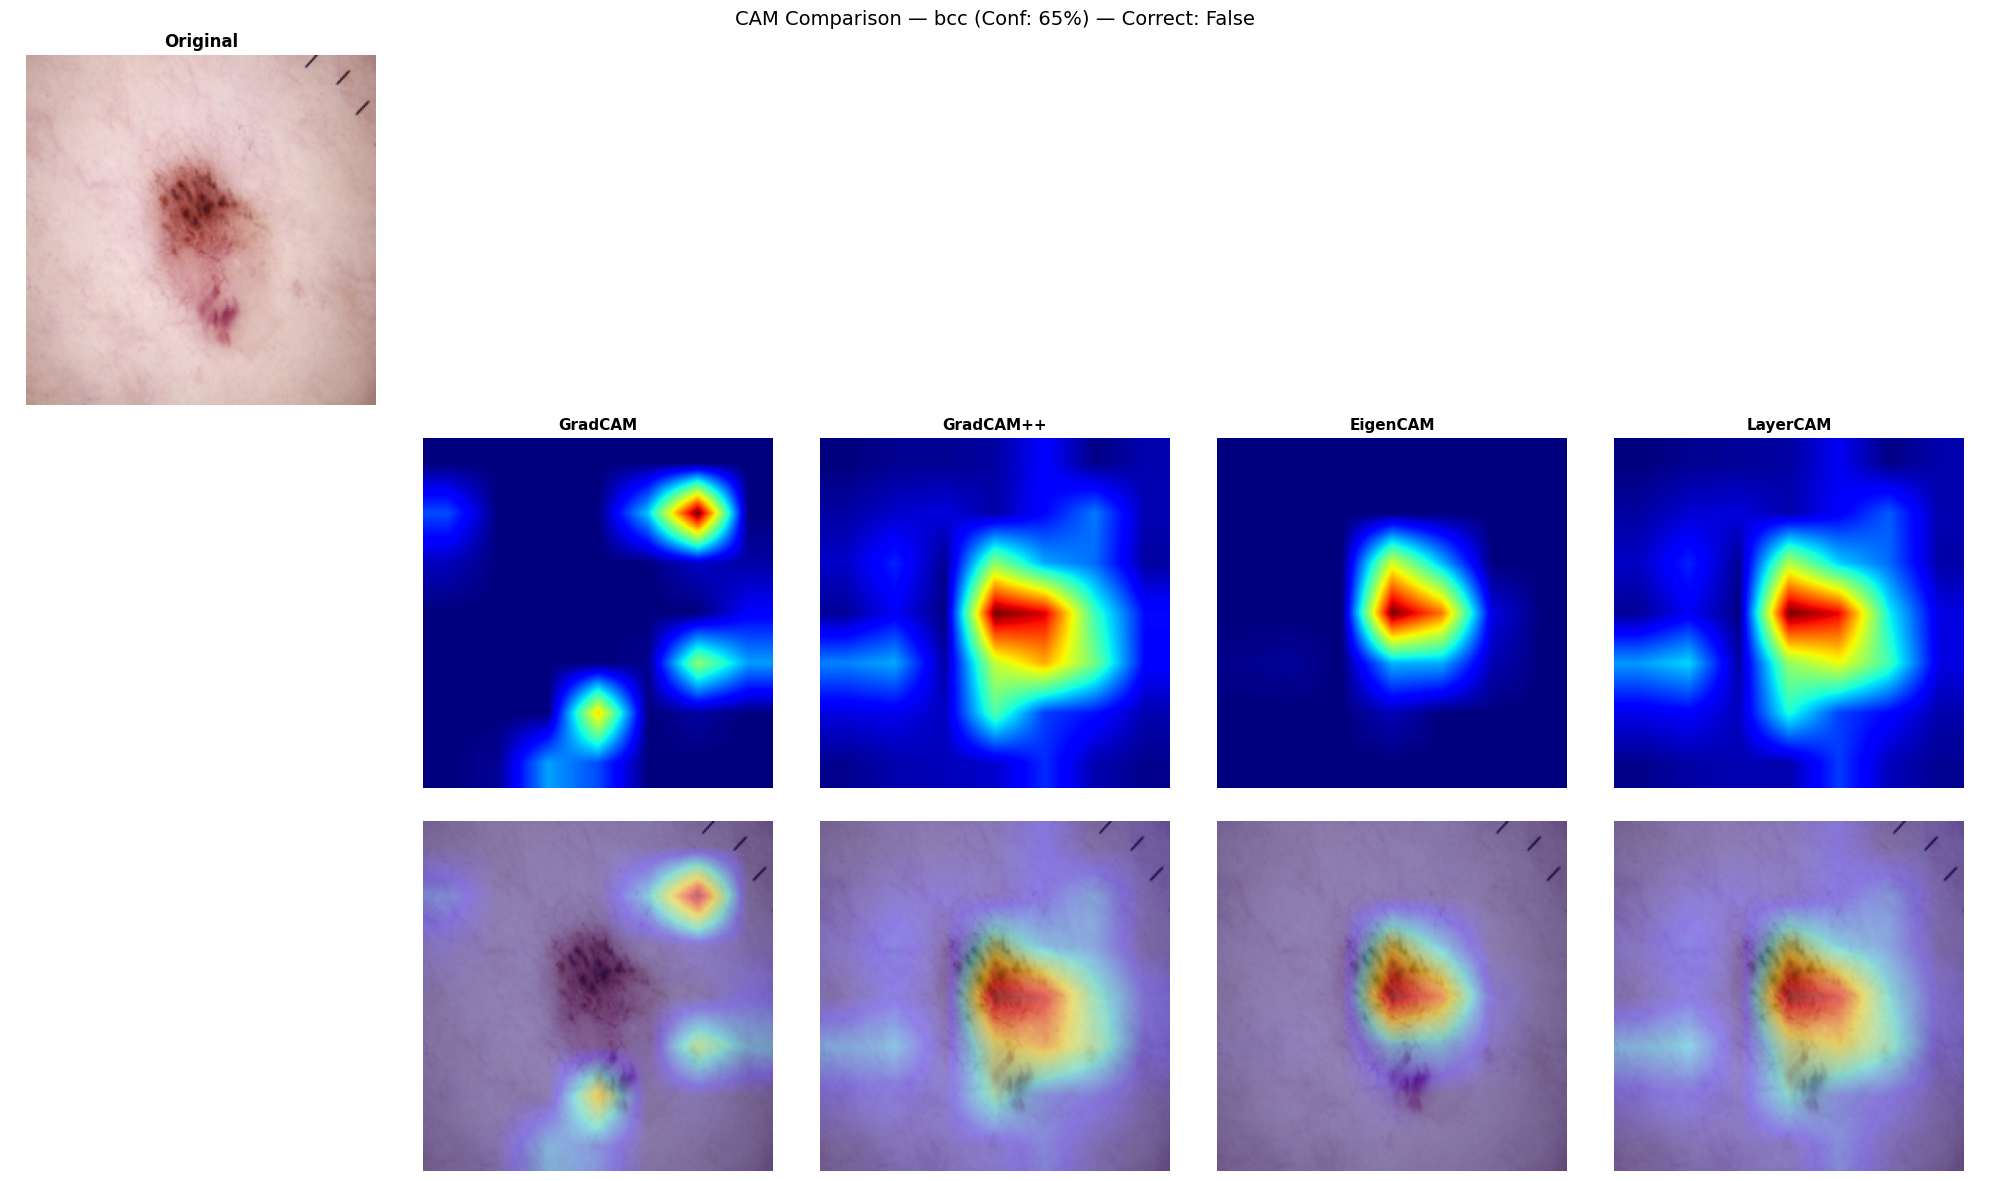

WHAT TO LOOK FOR:
  - GradCAM: broad, sometimes entire image lit up
  - GradCAM++: should be more focused on specific regions
  - EigenCAM: may highlight different features entirely
  - LayerCAM: finest-grained, sometimes patchy


In [5]:
import os
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)
import matplotlib.cm as cm

n = len(cam_maps)
fig, axes = plt.subplots(3, n + 1, figsize=(4 * (n + 1), 12))

# Row 0: Original
axes[0][0].imshow(img_float)
axes[0][0].set_title('Original', fontweight='bold')
axes[0][0].axis('off')
for i in range(1, n + 1):
    axes[0][i].axis('off')

# Rows 1 + 2: Heatmap and Overlay for each method
for col, (method_name, cam) in enumerate(cam_maps.items(), start=1):
    # Heatmap
    heatmap_colored = cm.jet(cam)[:, :, :3]
    axes[1][col].imshow(heatmap_colored)
    axes[1][col].set_title(method_name, fontsize=11, fontweight='bold')
    axes[1][col].axis('off')

    # Overlay
    alpha = 0.4
    overlay = (1 - alpha) * img_float + alpha * heatmap_colored
    overlay = np.clip(overlay, 0, 1)
    axes[2][col].imshow(overlay)
    axes[2][col].axis('off')

axes[1][0].set_ylabel('Heatmap', fontsize=12)
axes[2][0].set_ylabel('Overlay', fontsize=12)
axes[1][0].axis('off')
axes[2][0].axis('off')

plt.suptitle(
    f'CAM Comparison — {sample["dx"]} (Conf: {conf*100:.0f}%) — '
    f'Correct: {pred == sample["label"]}',
    fontsize=14
)
plt.tight_layout()
plt.savefig('outputs/figures/RQ1_single_image_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("WHAT TO LOOK FOR:")
print("  - GradCAM: broad, sometimes entire image lit up")
print("  - GradCAM++: should be more focused on specific regions")
print("  - EigenCAM: may highlight different features entirely")
print("  - LayerCAM: finest-grained, sometimes patchy")

In [6]:
# ─── Self-contained: check prerequisites ───
try:
    cam_maps
except NameError:
    print("❌ Prerequisites not loaded. Run CELLS 3 and 5 first.")
    raise NameError("Run CELLS 3 and 5 first.")

def focus_area_percentage(cam, threshold=0.5):
    """Fraction of pixels with CAM value above threshold."""
    return float((cam >= threshold).sum() / cam.size)

def cam_entropy(cam):
    cam_flat = cam.flatten()
    cam_flat = cam_flat / (cam_flat.sum() + 1e-8)
    return -np.sum(cam_flat * np.log(cam_flat + 1e-8))

def max_activation_location(cam):
    flat_idx = np.argmax(cam)
    h, w = cam.shape
    row = flat_idx // w
    col = flat_idx % w
    return row / h, col / w

print("=== RQ1 Metrics for Single Image ===\n")
print(f"{'Method':<12} {'FAP@0.5':>8} {'FAP@0.3':>8} {'Entropy':>10} {'Peak (row,col)':>15}")
print("-" * 60)
for method_name, cam in cam_maps.items():
    fap_05 = focus_area_percentage(cam, 0.5)
    fap_03 = focus_area_percentage(cam, 0.3)
    ent = cam_entropy(cam)
    row, col = max_activation_location(cam)
    print(f"{method_name:<12} {fap_05:>8.3f} {fap_03:>8.3f} {ent:>10.3f} ({row:.2f}, {col:.2f})")

print("\nINTERPRETATION:")
print("  Lower FAP → method focuses on smaller region")
print("  Lower Entropy → more concentrated (peaked) attention")
print("  Peak location → where the model 'looks' most")

=== RQ1 Metrics for Single Image ===

Method        FAP@0.5  FAP@0.3    Entropy  Peak (row,col)
------------------------------------------------------------
GradCAM         0.021    0.072      9.721 (0.21, 0.78)
GradCAM++       0.092    0.175     10.340 (0.50, 0.50)
EigenCAM        0.050    0.092      9.202 (0.50, 0.50)
LayerCAM        0.083    0.169     10.344 (0.50, 0.50)

INTERPRETATION:
  Lower FAP → method focuses on smaller region
  Lower Entropy → more concentrated (peaked) attention
  Peak location → where the model 'looks' most


In [7]:
def focus_area_percentage(cam, threshold=0.5):
    """Fraction of pixels with CAM value above threshold."""
    return float((cam >= threshold).sum() / cam.size)

def cam_entropy(cam):
    """
    Entropy of the normalized CAM distribution.
    LOW entropy = concentrated activation (focused)
    HIGH entropy = spread activation (diffuse)
    More nuanced than FAP because it doesn't depend on threshold choice.
    """
    cam_flat = cam.flatten()
    cam_flat = cam_flat / (cam_flat.sum() + 1e-8)
    return -np.sum(cam_flat * np.log(cam_flat + 1e-8))

def max_activation_location(cam):
    """Where is the most activated pixel? Returns (row, col) normalized to [0,1]."""
    flat_idx = np.argmax(cam)
    h, w = cam.shape
    row = flat_idx // w
    col = flat_idx % w
    return row / h, col / w

print("=== RQ1 Metrics for Single Image ===\n")
print(f"{'Method':<12} {'FAP@0.5':>8} {'FAP@0.3':>8} {'Entropy':>10} {'Peak (row,col)':>15}")
print("-" * 60)
for method_name, cam in cam_maps.items():
    fap_05 = focus_area_percentage(cam, 0.5)
    fap_03 = focus_area_percentage(cam, 0.3)
    ent = cam_entropy(cam)
    row, col = max_activation_location(cam)
    print(f"{method_name:<12} {fap_05:>8.3f} {fap_03:>8.3f} {ent:>10.3f} ({row:.2f}, {col:.2f})")

print("\nINTERPRETATION:")
print("  Lower FAP → method focuses on smaller region")
print("  Lower Entropy → more concentrated (peaked) attention")
print("  Peak location → where the model 'looks' most")

=== RQ1 Metrics for Single Image ===

Method        FAP@0.5  FAP@0.3    Entropy  Peak (row,col)
------------------------------------------------------------
GradCAM         0.021    0.072      9.721 (0.21, 0.78)
GradCAM++       0.092    0.175     10.340 (0.50, 0.50)
EigenCAM        0.050    0.092      9.202 (0.50, 0.50)
LayerCAM        0.083    0.169     10.344 (0.50, 0.50)

INTERPRETATION:
  Lower FAP → method focuses on smaller region
  Lower Entropy → more concentrated (peaked) attention
  Peak location → where the model 'looks' most


---

## CELL 5: Scale to N Images — Statistical Comparison

**WHY**: One image proves nothing. You need distribution-level evidence.
Target: 150+ correctly classified images for reliable statistics.

**NOTE**: This cell takes several minutes on CPU. Use GPU if available.

In [8]:
import os
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)
from tqdm import tqdm
import scipy.stats as stats

import sys
sys.path.append('../Skin_Lesion_Classification_backend/ml')

# Load test set (IMPORTANT: only use test set for final evaluation!)
from src.data.dataset import create_splits
_, _, test_df = create_splits(df)

# Filter to correctly classified images only
results = []
N_EVAL = 150  # start with 150, increase if you have time/GPU

eval_sample = test_df.sample(min(N_EVAL, len(test_df)), random_state=42)

for _, row in tqdm(eval_sample.iterrows(), total=len(eval_sample)):
    try:
        orig_img = np.array(Image.open(row['filepath']).convert('RGB').resize((224, 224)))
        input_t = transform(image=orig_img)['image'].unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(input_t)
            prob_mal = torch.sigmoid(out[0, 0]).item()
            pred_class = int(prob_mal > 0.5)
            confidence = prob_mal if pred_class == 1 else 1 - prob_mal

        # ONLY process correctly classified images
        if pred_class != int(row['label']):
            continue

        for method_name, cam_class in cam_variants.items():
            with cam_class(model=model, target_layers=[target_layer]) as cam_gen:
                cam = cam_gen(input_tensor=input_t, targets=[ClassifierOutputTarget(0)])[0]

            results.append({
                'image_id':   row['image_id'],
                'dx':         row['dx'],
                'label':      row['label'],
                'confidence': confidence,
                'method':     method_name,
                'fap_05':     focus_area_percentage(cam, 0.5),
                'fap_03':     focus_area_percentage(cam, 0.3),
                'entropy':    cam_entropy(cam),
            })

    except Exception as e:
        print(f"Skipping {row['image_id']}: {e}")

results_df = pd.DataFrame(results)
results_df.to_csv('outputs/metrics/RQ1_cam_comparison.csv', index=False)
print(f"\nProcessed {results_df['image_id'].nunique()} images")
print(f"Results rows: {len(results_df)}")
print(results_df.groupby('method')[['fap_05', 'entropy']].describe().round(4))

100%|██████████| 150/150 [00:52<00:00,  2.88it/s]


Processed 121 images
Results rows: 484
          fap_05                                                          \
           count    mean     std     min     25%     50%     75%     max   
method                                                                     
EigenCAM   121.0  0.0791  0.0760  0.0195  0.0429  0.0619  0.0898  0.6114   
GradCAM    121.0  0.0397  0.0514  0.0000  0.0000  0.0184  0.0608  0.1961   
GradCAM++  121.0  0.0931  0.0485  0.0242  0.0563  0.0856  0.1166  0.2571   
LayerCAM   121.0  0.0936  0.0487  0.0243  0.0536  0.0884  0.1207  0.2545   

          entropy                                                               
            count     mean     std     min      25%      50%      75%      max  
method                                                                          
EigenCAM    121.0   9.5250  0.3366  8.8586   9.3228   9.4990   9.7209  10.5951  
GradCAM     121.0   5.4580  4.7284 -0.0000   0.0000   8.1510   9.9273  10.5581  
GradCAM++   121.0  10.

---

## CELL 6: Statistical Testing — This Is What Makes It Science

**WHY**: You need to know if differences between methods are real or just random variation.
Use a paired test because each image is evaluated by ALL methods.

In [9]:
import scipy.stats as stats
import seaborn as sns

# Summary statistics per method
print("=== Method Comparison (Focus Area %) ===\n")
summary = results_df.groupby('method')['fap_05'].agg(['mean', 'std', 'median', 'count'])
print(summary.round(4))

# Statistical test: Kruskal-Wallis (non-parametric ANOVA)
# Use this because CAM distributions are rarely normal
# It tests: "Are any of these methods significantly different?"
groups = [results_df[results_df['method'] == m]['fap_05'].values 
          for m in results_df['method'].unique()]
h_stat, p_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis test: H={h_stat:.3f}, p={p_kw:.4f}")
if p_kw < 0.05:
    print("\u2705 Significant difference between methods (p < 0.05)")
    print("→ At least one method focuses on significantly different regions")
else:
    print("\u274c No significant difference — methods produce similar focus areas")

# Pairwise tests (Wilcoxon signed-rank — paired because same images)
methods = results_df['method'].unique()
print("\n=== Pairwise Wilcoxon Tests (Focus Area) ===")
print(f"{'Method A':<12} vs {'Method B':<12}  {'p-value':>10}  {'Significant':>12}")
print("-" * 55)
for i, m1 in enumerate(methods):
    for m2 in methods[i+1:]:
        paired = results_df[results_df['method'].isin([m1, m2])].pivot_table(
            index='image_id', columns='method', values='fap_05'
        ).dropna()
        stat, p = stats.wilcoxon(paired[m1], paired[m2])
        sig = "\u2705 YES" if p < 0.05 else "\u274c no"
        print(f"{m1:<12} vs {m2:<12}  {p:>10.4f}  {sig:>12}")

# Effect size: Cohen's d
print("\n=== Effect Sizes (Cohen's d) ===")
for i, m1 in enumerate(methods):
    for m2 in methods[i+1:]:
        d1 = results_df[results_df['method'] == m1]['fap_05'].values
        d2 = results_df[results_df['method'] == m2]['fap_05'].values
        pooled_std = np.sqrt((d1.std()**2 + d2.std()**2) / 2)
        cohen_d = abs(d1.mean() - d2.mean()) / pooled_std
        magnitude = "small" if cohen_d < 0.5 else "medium" if cohen_d < 0.8 else "LARGE"
        print(f"{m1} vs {m2}: d = {cohen_d:.3f} ({magnitude})")

=== Method Comparison (Focus Area %) ===

             mean     std  median  count
method                                  
EigenCAM   0.0791  0.0760  0.0619    121
GradCAM    0.0397  0.0514  0.0184    121
GradCAM++  0.0931  0.0485  0.0856    121
LayerCAM   0.0936  0.0487  0.0884    121

Kruskal-Wallis test: H=105.305, p=0.0000
✅ Significant difference between methods (p < 0.05)
→ At least one method focuses on significantly different regions

=== Pairwise Wilcoxon Tests (Focus Area) ===
Method A     vs Method B         p-value   Significant
-------------------------------------------------------
GradCAM      vs GradCAM++         0.0000         ✅ YES
GradCAM      vs EigenCAM          0.0000         ✅ YES
GradCAM      vs LayerCAM          0.0000         ✅ YES
GradCAM++    vs EigenCAM          0.0000         ✅ YES
GradCAM++    vs LayerCAM          0.6932          ❌ no
EigenCAM     vs LayerCAM          0.0000         ✅ YES

=== Effect Sizes (Cohen's d) ===
GradCAM vs GradCAM++: d = 1.072 

---

## CELL 7: Paper-Quality Visualizations

C:\Users\saiyu\AppData\Local\Temp\ipykernel_20828\2145647128.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='method', y='fap_05', ax=axes[0], palette='Set2')
C:\Users\saiyu\AppData\Local\Temp\ipykernel_20828\2145647128.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=results_df, x='method', y='entropy', ax=axes[1], palette='Set2')


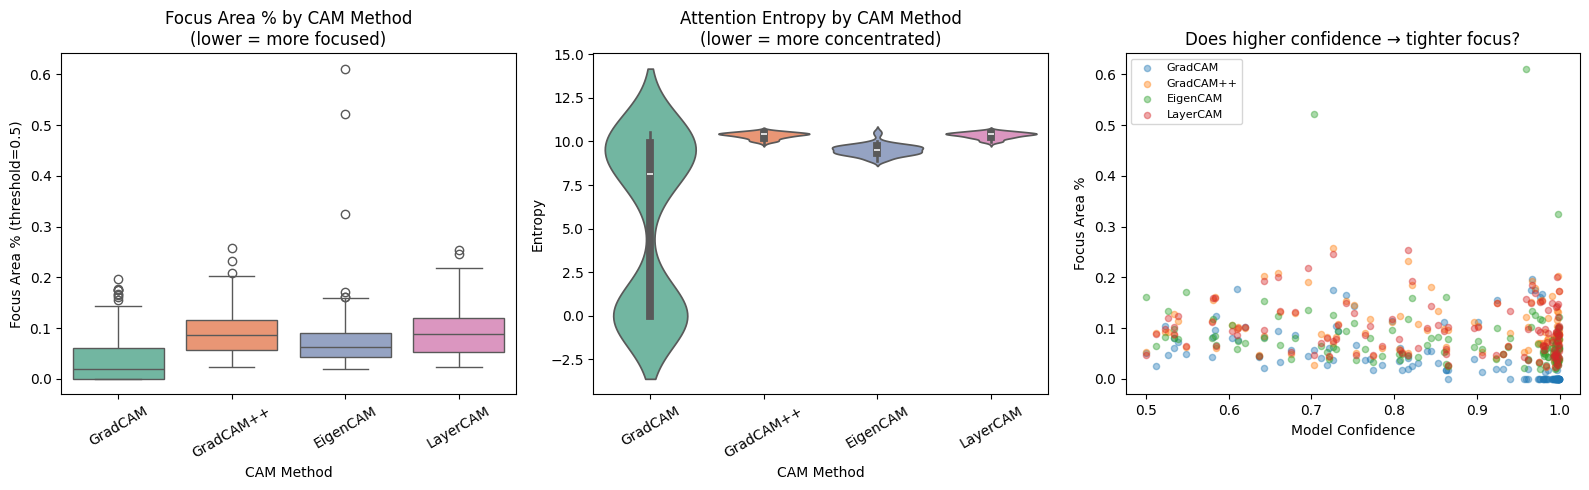

=== FAP vs Confidence Correlations ===
GradCAM: r=-0.473, p=0.0000 ✅
GradCAM++: r=-0.199, p=0.0283 ✅
EigenCAM: r=-0.165, p=0.0711 
LayerCAM: r=-0.168, p=0.0657 


In [10]:
import os
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Box plot of FAP by method
sns.boxplot(data=results_df, x='method', y='fap_05', ax=axes[0], palette='Set2')
axes[0].set_title('Focus Area % by CAM Method\n(lower = more focused)', fontsize=12)
axes[0].set_xlabel('CAM Method')
axes[0].set_ylabel('Focus Area % (threshold=0.5)')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Entropy distribution
sns.violinplot(data=results_df, x='method', y='entropy', ax=axes[1], palette='Set2')
axes[1].set_title('Attention Entropy by CAM Method\n(lower = more concentrated)', fontsize=12)
axes[1].set_xlabel('CAM Method')
axes[1].set_ylabel('Entropy')
axes[1].tick_params(axis='x', rotation=30)

# Plot 3: FAP vs Confidence
for method in results_df['method'].unique():
    sub = results_df[results_df['method'] == method]
    axes[2].scatter(sub['confidence'], sub['fap_05'], alpha=0.4, s=20, label=method)
axes[2].set_xlabel('Model Confidence')
axes[2].set_ylabel('Focus Area %')
axes[2].set_title('Does higher confidence → tighter focus?', fontsize=12)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/RQ1_statistical_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation: FAP vs Confidence per method
print("=== FAP vs Confidence Correlations ===")
for method in results_df['method'].unique():
    sub = results_df[results_df['method'] == method]
    r, p = stats.pearsonr(sub['confidence'], sub['fap_05'])
    print(f"{method}: r={r:.3f}, p={p:.4f} {'\u2705' if p < 0.05 else ''}")